### Find file paths

In [14]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f == 'vision_common_v8.py':
            print(os.path.join(root, f))

/kaggle/input/datasets/maryclauds/vision-common-v8/vision_common_v8.py


# Detect the arcu marker used

In [12]:
import cv2
import os
import glob
import re
from collections import defaultdict
import time

train_dir = '/kaggle/input/datasets/maryclauds/combined-final-final-dataset/combined_final_final_dataset'

# Candidate dictionaries to test
candidates = {
    "4X4_50":          cv2.aruco.DICT_4X4_50,
    "5X5_50":          cv2.aruco.DICT_5X5_50,
    "5X5_100":         cv2.aruco.DICT_5X5_100,
    "6X6_50":          cv2.aruco.DICT_6X6_50,
    "6X6_100":         cv2.aruco.DICT_6X6_100,
    "7X7_50":          cv2.aruco.DICT_7X7_50,
    "ARUCO_MIP_36H12": cv2.aruco.DICT_ARUCO_MIP_36H12,
}

detectors = {}
params = cv2.aruco.DetectorParameters()
for name, const in candidates.items():
    adict = cv2.aruco.getPredefinedDictionary(const)
    detectors[name] = cv2.aruco.ArucoDetector(adict, params)

# --- Find all images ---
exts = ("*.jpg", "*.jpeg", "*.png")
all_files = []
for ext in exts:
    all_files.extend(glob.glob(os.path.join(train_dir, "**", ext), recursive=True))
print(f"Found {len(all_files)} images total.")

# --- Group key: parent folder name if nested, else filename prefix before first underscore/digit run ---
def group_key(filepath):
    parent = os.path.basename(os.path.dirname(filepath))
    if parent and parent != os.path.basename(train_dir.rstrip('/')):
        return parent
    fname = os.path.basename(filepath)
    m = re.match(r'^([A-Za-z]*\d*)', fname)
    return m.group(1) if m else fname

# results[group][dict_name] = hit_count ; totals[group] = total images
results = defaultdict(lambda: defaultdict(int))
totals = defaultdict(int)

start = time.time()
for i, f in enumerate(all_files):
    img = cv2.imread(f)
    if img is None:
        continue
    g = group_key(f)
    totals[g] += 1
    for name, detector in detectors.items():
        corners, ids, _ = detector.detectMarkers(img)
        if ids is not None and len(ids) > 0:
            results[g][name] += 1
    if (i + 1) % 100 == 0:
        elapsed = time.time() - start
        print(f"  {i+1}/{len(all_files)} processed ({elapsed:.1f}s elapsed)")

print(f"\nDone in {time.time() - start:.1f}s\n")

# --- Summary ---
print(f"{'Group':<20}{'Total':<8}" + "".join(f"{name:<16}" for name in candidates))
for g in sorted(totals, key=lambda k: -totals[k]):
    row = f"{g:<20}{totals[g]:<8}"
    for name in candidates:
        hits = results[g].get(name, 0)
        row += f"{hits}/{totals[g]:<12}"
    print(row)

Found 1000 images total.
  100/1000 processed (26.7s elapsed)
  200/1000 processed (52.3s elapsed)
  300/1000 processed (78.5s elapsed)
  400/1000 processed (104.2s elapsed)
  500/1000 processed (130.4s elapsed)
  600/1000 processed (156.8s elapsed)
  700/1000 processed (183.1s elapsed)
  800/1000 processed (209.6s elapsed)
  900/1000 processed (236.0s elapsed)
  1000/1000 processed (262.5s elapsed)

Done in 262.5s

Group               Total   4X4_50          5X5_50          5X5_100         6X6_50          6X6_100         7X7_50          ARUCO_MIP_36H12 
capture             1000    0/1000        256/1000        256/1000        0/1000        0/1000        0/1000        60/1000        


### run overlap test

In [13]:
# Do the 36h12 "hits" overlap with the 5x5 hits, or are they a distinct set?
det_5x5 = detectors["5X5_100"]
det_36h12 = detectors["ARUCO_MIP_36H12"]

overlap = 0
only_36h12 = []
for f in all_files:
    img = cv2.imread(f)
    if img is None:
        continue
    _, ids_5x5, _ = det_5x5.detectMarkers(img)
    _, ids_36h12, _ = det_36h12.detectMarkers(img)
    hit_5x5 = ids_5x5 is not None and len(ids_5x5) > 0
    hit_36h12 = ids_36h12 is not None and len(ids_36h12) > 0
    if hit_5x5 and hit_36h12:
        overlap += 1
    elif hit_36h12 and not hit_5x5:
        only_36h12.append(f)

print(f"Overlap (both fire): {overlap}")
print(f"36h12-only hits: {len(only_36h12)}")
print(only_36h12[:10])

Overlap (both fire): 56
36h12-only hits: 4
['/kaggle/input/datasets/maryclauds/combined-final-final-dataset/combined_final_final_dataset/capture__circle_pos_3_5.jpg', '/kaggle/input/datasets/maryclauds/combined-final-final-dataset/combined_final_final_dataset/capture__circle_height2_1.jpg', '/kaggle/input/datasets/maryclauds/combined-final-final-dataset/combined_final_final_dataset/capture_all_3.jpg', '/kaggle/input/datasets/maryclauds/combined-final-final-dataset/combined_final_final_dataset/capture_3_49.jpg']


### Import the vision-common

In [15]:
import os
import sys

# Confirm vision-common actually mounted, and under what exact folder name -
# Kaggle sometimes normalizes the slug slightly differently than you typed.
print(os.listdir('/kaggle/input'))
sys.path.append('/kaggle/input/datasets/maryclauds/vision-common-v8')

from vision_common_v8 import (
    rectify_workspace,
    detect_marker,
    extract_shape_features,
    find_valid_contours,
    compute_contour_features,
)


['datasets']


### Train dir

In [16]:
train_dir = '/kaggle/input/datasets/maryclauds/combined-final-final-dataset/combined_final_final_dataset'

In [17]:
"""
Run this in Kaggle against your dataset folder. It shows every unique
"raw label" the filename regex is actually extracting, and how many files
fall under each - so we can see exactly why star/hexagon aren't matching
LABEL_MAP without guessing.
"""

import os
import re
from collections import Counter

train_dir = '/kaggle/input/datasets/maryclauds/combined-final-final-dataset/combined_final_final_dataset'

FILENAME_PATTERN = re.compile(
    r'^capture_(?P<label>.+)_(?P<idx>\d+)\.(jpg|jpeg|png)$',
    re.IGNORECASE
)

raw_labels = Counter()
unmatched = []

for filename in os.listdir(train_dir):
    m = FILENAME_PATTERN.match(filename)
    if not m:
        unmatched.append(filename)
        continue
    raw_labels[m.group('label').lower()] += 1

print("=== Raw label -> file count ===")
for label, count in raw_labels.most_common():
    print(f"  '{label}': {count} files")

if unmatched:
    print(f"\n=== {len(unmatched)} files didn't match the pattern at all (showing up to 10) ===")
    for f in unmatched[:10]:
        print("  ", f)

=== Raw label -> file count ===
  '2': 51 files
  '6': 51 files
  '3': 51 files
  '10': 51 files
  '9': 51 files
  '4': 51 files
  '7': 51 files
  '11': 51 files
  '5': 51 files
  '1': 51 files
  'aruco_3_shapes': 30 files
  'aruco': 30 files
  'all': 30 files
  '12': 29 files
  'square': 22 files
  '_circle_pos_1': 10 files
  '_circle_pos_2': 10 files
  '_circle_pos_6': 10 files
  '_circle_pos_5': 10 files
  '_circle_pos_3': 10 files
  '_circle_pos_4': 10 files
  '_circle_pos_7': 10 files
  '_circle_pos_8': 10 files
  '_square_height4': 5 files
  '_square_pos_8': 5 files
  '_star_pos_5': 5 files
  '_star_pos_2': 5 files
  '_square_pos_7': 5 files
  '_star_pos_10': 5 files
  '_circle_height4': 5 files
  '_circle_height11': 5 files
  '_circle_height3': 5 files
  '_star_pos_14': 5 files
  '_square_pos_3': 5 files
  '_star_pos_9': 5 files
  '_star_pos_4': 5 files
  '_circle_height12': 5 files
  '_circle_height8': 5 files
  '_star_height4': 5 files
  '_star_height5': 5 files
  '_star_heigh

In [26]:
"""
Loader for the full dataset. Two filename families now feed in:

  1) Original clean single-shape captures:
       capture_star_N.jpg / capture_square_N.jpg / capture_hex_N.jpg
     (one shape type per photo, well-lit, independently captured)

  2) New batch, different lighting exposure, added for robustness.
     Raw numeric label -> what's actually in frame:
       1  = aruco + square                -> single type (Square)  -> USE
       2  = aruco + square + star         -> multi type             -> EXCLUDE
       3  = aruco + square + star + hex   -> multi type             -> EXCLUDE
       4  = aruco + square + star + hex   -> multi type             -> EXCLUDE
       5  = aruco + square + star + hex + square -> multi type      -> EXCLUDE
       6  = aruco + square + star + hex + square -> multi type      -> EXCLUDE
       7  = square + square               -> single type (Square)  -> USE
       8  = hex                           -> single type (Hexagon) -> EXLUDE
       9  = star                          -> single type (Star)    -> USE
       10 = star                          -> single type (Star)    -> USE
       11 = aruco only                    -> marker-only            -> EXCLUDE
       12 = aruco only                    -> marker-only            -> EXCLUDE

     Labels 2-6 are excluded from classifier training: with more than one
     shape TYPE in frame, a single filename label can't be assigned to the
     right contour without knowing which contour is which - same reasoning
     that already excluded `aruco_3_shapes`. These frames are still useful
     later for testing the *live* multi-shape detection pipeline
     (find_valid_contours + per-contour classify in main_vision.py) - just
     not as labeled training rows here.

     Labels 11/12 are excluded for the same reason `aruco` always was:
     marker only, no shape to learn from.

IMPORTANT CHANGE: this now uses find_valid_contours() (ALL valid contours
in the frame) instead of extract_shape_features()'s largest-contour-only
behaviour. For single-shape-type frames this is free extra training data
whenever more than one instance of that shape is in frame (e.g. raw label
7, "square + square", now yields 2 training rows instead of 1). For the
old-style one-shape-per-photo captures it behaves identically to before
(exactly one valid contour), so this is a strict improvement, not a
behaviour change for the existing 593 samples.
"""

import re
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import pandas as pd
from collections import Counter

FILENAME_PATTERN = re.compile(
    r"^capture_(?P<label>.+)_(?P<idx>\d+)\.(jpg|jpeg|png)$",
    re.IGNORECASE
)

#LABEL_MAP = {
 #   "star": "Star",
 #   "square": "Square",
 #   "hex": "Hexagon",
 #   "1": "Square",    # aruco + square
 #   "7": "Square",    # square + square
 #   "8": "Hexagon",   # hex only
 #   "9": "Star",      # star only
#    "10": "Star",     # star only
#}

# Raw labels we've confirmed are multi-shape-type or marker-only, so we can
# tell "known, deliberately excluded" apart from "unrecognized, check this"
# in the skip printout below.
KNOWN_EXCLUDED_RAW_LABELS = {
    "2", "3", "4", "5", "6", "11", "12", 
    "aruco", "aruco_3_shapes", "all",
    "hex", "8"
}

def resolve_label(raw_label):
    """Dynamically map raw labels to target classes using substrings."""
    if raw_label in KNOWN_EXCLUDED_RAW_LABELS or "hex" in raw_label:
        return None
    if "circle" in raw_label:
        return "Circle"
    if "square" in raw_label or raw_label in ["1", "7"]:
        return "Square"
    if "star" in raw_label or raw_label in ["9", "10"]:
        return "Star"
    return None


def load_labeled_dataset(folder_path):
    X, y = [], []
    skipped_known_excluded = Counter()
    skipped_unrecognized = Counter()
    skipped_no_contour = 0
    skipped_no_paper = 0
    skipped_no_marker = 0
    used_raw_label_counts = Counter()
    used_raw_label_sample_counts = Counter()

    for filename in os.listdir(folder_path):
        m = FILENAME_PATTERN.match(filename)
        if not m:
            continue

        raw_label = m.group("label").lower()
        label = resolve_label(raw_label)

        if label is None:
            # Catch known exclusions and any variations of hex
            if raw_label in KNOWN_EXCLUDED_RAW_LABELS or "hex" in raw_label:
                skipped_known_excluded[raw_label] += 1
            else:
                skipped_unrecognized[raw_label] += 1
            continue

        image_path = os.path.join(folder_path, filename)
        img = cv2.imread(image_path)
        if img is None:
            continue

        # 1) Rectify FIRST — crop the frame down to just the paper.
        rectified = rectify_workspace(img)
        if rectified is None:
            # Paper's corners weren't found. Two choices:
            #  (a) skip the sample entirely (cleanest), or
            #  (b) fall back to the raw frame (what preprocess_frame does).
            # For TRAINING, skipping is safer — you don't want a sample whose
            # feature vector is contaminated by the table.
            skipped_no_paper += 1
            continue
        img = rectified

        # 2) Now detect marker/shape in the rectified image. Coordinates,
        #    mm_per_px and angle are all in rectified space, which is what
        #    compute_contour_features expects.
        # 2) Now detect marker/shape in the rectified image.
        marker = detect_marker(img)
        exclude_bbox = marker["bbox"] if marker else None
        valid_contours = find_valid_contours(img, exclude_bbox=exclude_bbox)
            
        if not valid_contours:
            skipped_no_contour += 1
            continue

        used_raw_label_counts[raw_label] += 1
        for c in valid_contours:
            features = compute_contour_features(c)
            if features is None:
                continue
            
            # REMOVED the marker_present feature append here
            X.append(features)
            y.append(label)
            used_raw_label_sample_counts[raw_label] += 1

    print(f"Loaded {len(X)} labeled samples.")
    print(f"Skipped {skipped_no_paper} files where the paper wasn't found.")
    print(f"Skipped {skipped_no_marker} files where no ArUco marker was detected.")
    print(f"Skipped {skipped_no_contour} files with no valid shape contour.")

    print(f"Loaded {len(X)} labeled samples.")
    print(f"Skipped {skipped_no_contour} labeled files with no valid contour found - spot-check these.")

    print("\n=== Raw labels used, by files -> training rows ===")
    for raw_label, file_count in sorted(used_raw_label_counts.items()):
        mapped_label = resolve_label(raw_label)
        print(f"  '{raw_label}' -> {mapped_label}: {file_count} files, "
              f"{used_raw_label_sample_counts[raw_label]} rows "
              f"({used_raw_label_sample_counts[raw_label] - file_count} extra from multi-instance frames)")

    if skipped_known_excluded:
        print("\n=== Skipped - known excluded (multi-shape-type, marker-only, or hex) ===")
        for raw_label, count in sorted(skipped_known_excluded.items()):
            print(f"  '{raw_label}': {count} files")

    if skipped_unrecognized:
        print("\n=== Skipped - UNRECOGNIZED raw label ===")
        for raw_label, count in sorted(skipped_unrecognized.items()):
            print(f"  '{raw_label}': {count} files")

    print("\n=== Final class balance ===")
    for shape in sorted(set(y)):
        print(f"  {shape}: {y.count(shape)} samples")

    return np.array(X), np.array(y)


## Load the data


In [27]:
X, y = load_labeled_dataset(train_dir)


Loaded 814 labeled samples.
Skipped 0 files where the paper wasn't found.
Skipped 0 files where no ArUco marker was detected.
Skipped 24 files with no valid shape contour.
Loaded 814 labeled samples.
Skipped 24 labeled files with no valid contour found - spot-check these.

=== Raw labels used, by files -> training rows ===
  '1' -> Square: 51 files, 90 rows (39 extra from multi-instance frames)
  '10' -> Star: 51 files, 114 rows (63 extra from multi-instance frames)
  '7' -> Square: 51 files, 116 rows (65 extra from multi-instance frames)
  '9' -> Star: 51 files, 72 rows (21 extra from multi-instance frames)
  '_circle_height1' -> Circle: 5 files, 5 rows (0 extra from multi-instance frames)
  '_circle_height10' -> Circle: 5 files, 5 rows (0 extra from multi-instance frames)
  '_circle_height11' -> Circle: 5 files, 5 rows (0 extra from multi-instance frames)
  '_circle_height12' -> Circle: 5 files, 5 rows (0 extra from multi-instance frames)
  '_circle_height2' -> Circle: 5 files, 5 row

## Stratified 80/20 split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

# ADD STEP 2 HERE: Keep only the first 9 features (6 base + 3 Hu moments)
X_train_reduced = X_train[:, :9]
X_test_reduced = X_test[:, :9]


Train: 651  Test: 163


#### confirm the crop fix works

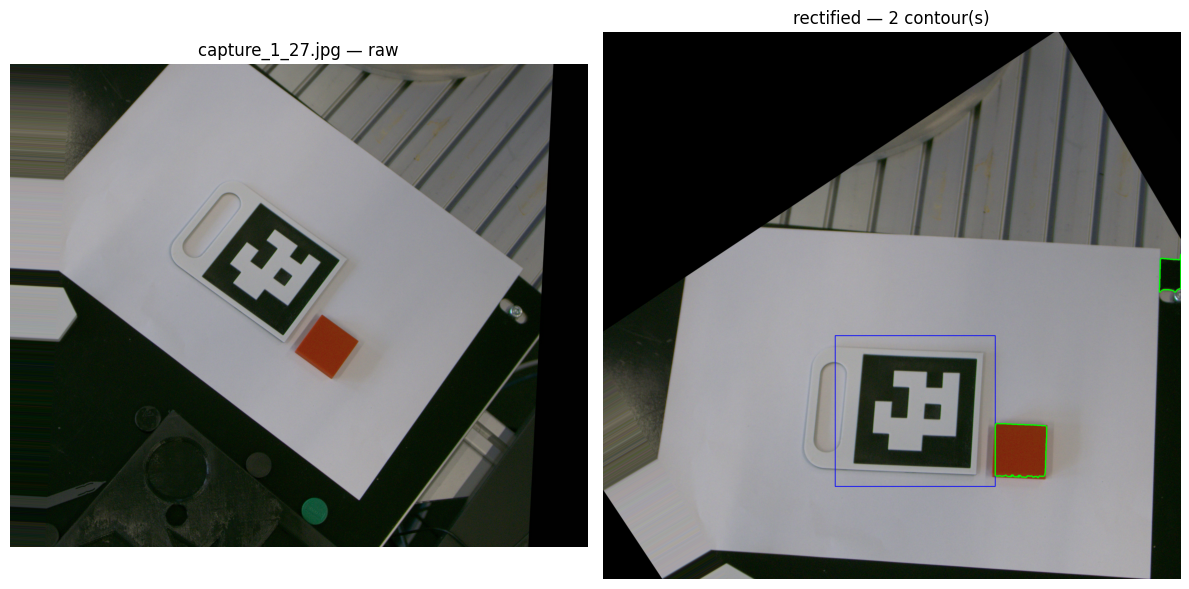

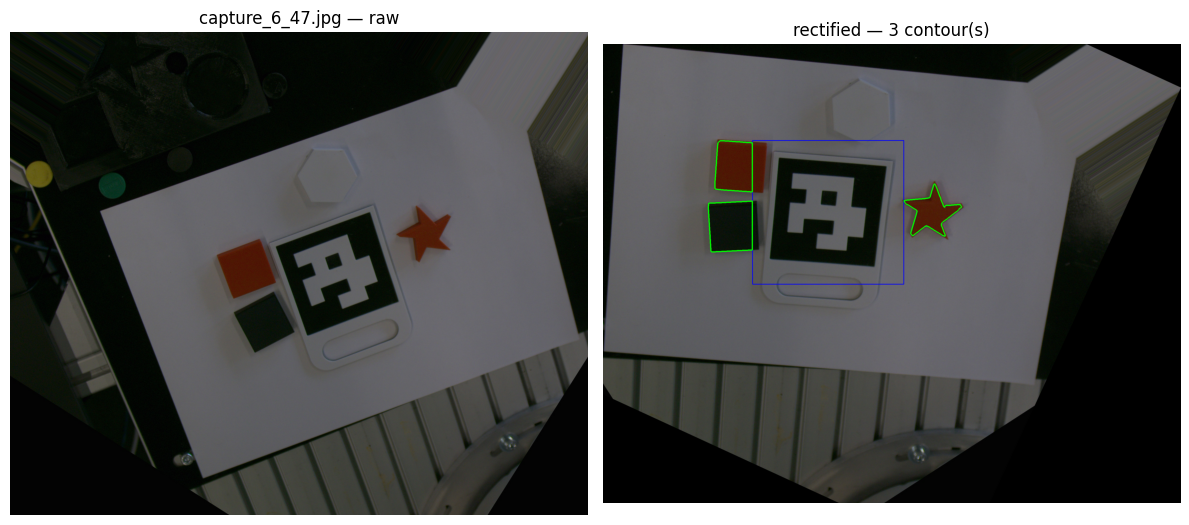

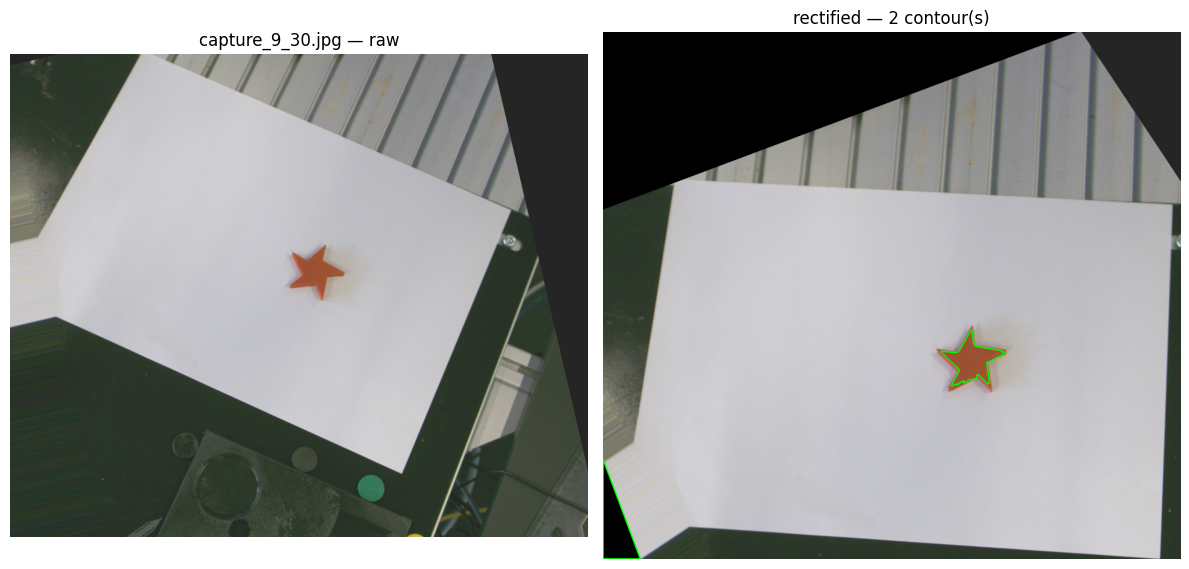

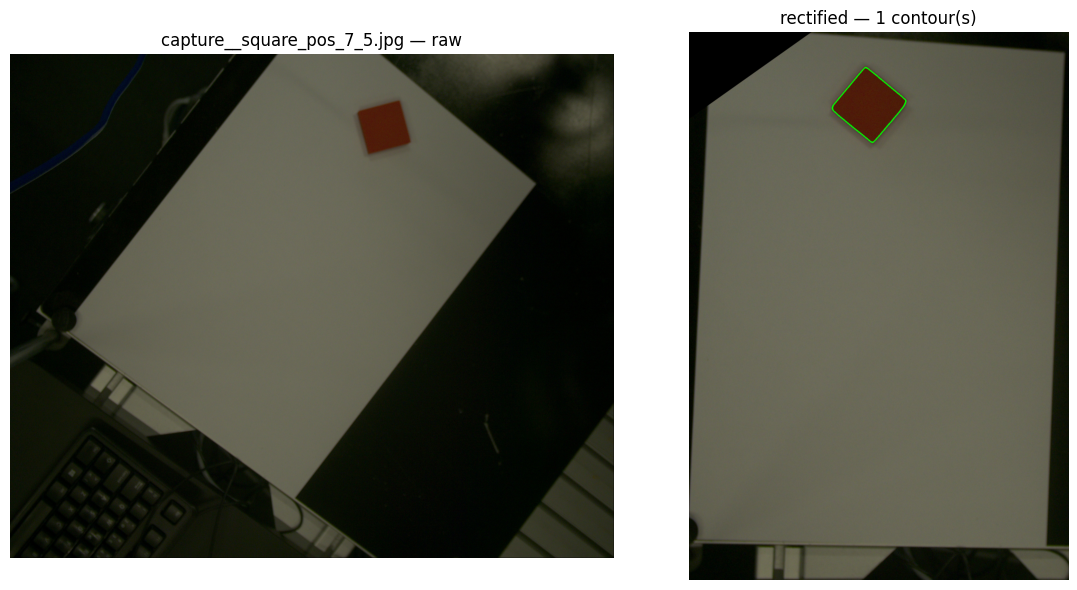

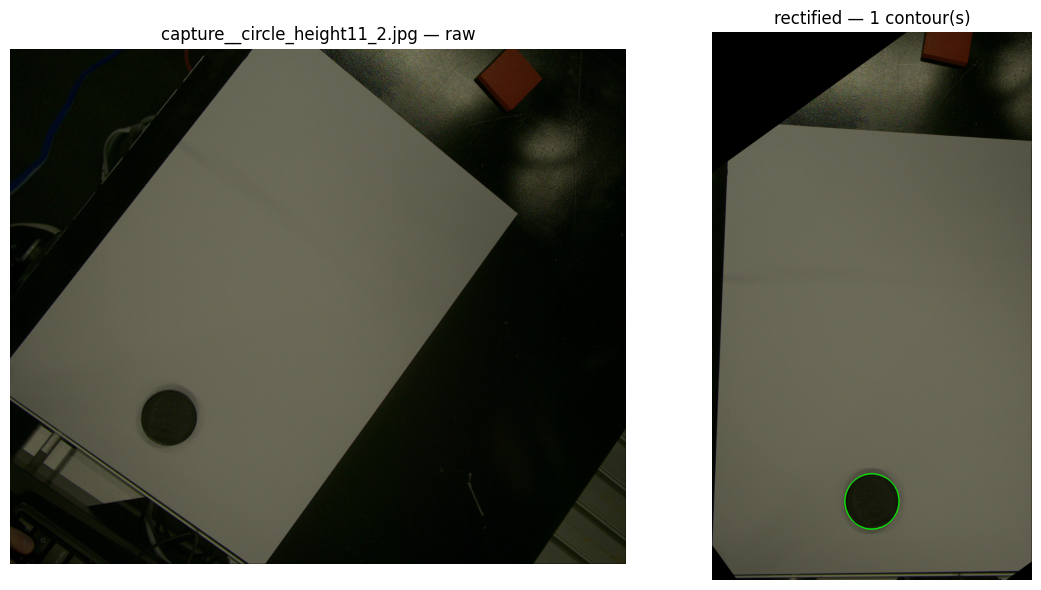

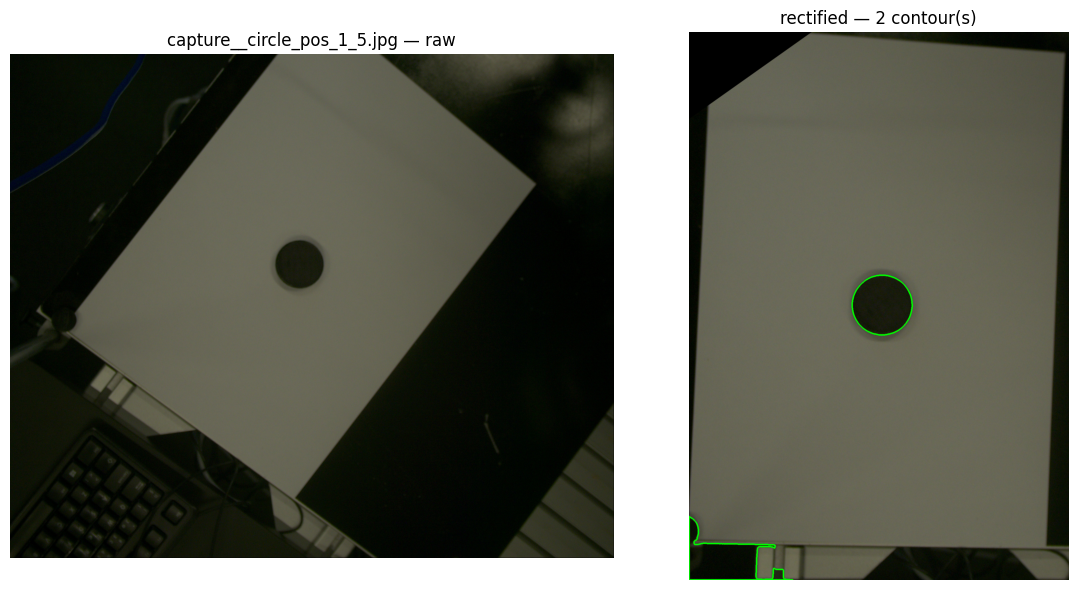

In [36]:
import vision_common_v8
import matplotlib.pyplot as plt  
#print(vision_common_v6.VISION_COMMON_VERSION)  # should print v5_workspace_crop

sample_files = ['capture_1_27.jpg','capture_6_47.jpg',
                'capture_9_30.jpg','capture__square_pos_7_5.jpg','capture__circle_height11_2.jpg', 'capture__circle_pos_1_5.jpg']

for fname in sample_files:
    raw = cv2.imread(os.path.join(train_dir, fname))
    rect = rectify_workspace(raw)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"{fname} — raw")

    if rect is None:
        axes[1].text(0.5, 0.5, "paper NOT found\n(sample would be skipped)",
                     ha='center', va='center', fontsize=14)
        axes[1].axis('off')
    else:
        marker = detect_marker(rect)
        contours = find_valid_contours(
            rect, exclude_bbox=marker["bbox"] if marker else None
        )
        vis = rect.copy()
        if marker:
            x, y, w, h = marker["bbox"]
            cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.drawContours(vis, contours, -1, (0, 255, 0), 3)
        axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"rectified — {len(contours)} contour(s)")

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### Train with XGBOOST

In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# STEP 3: Encode labels and compute class weights
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# STEP 4: Train and evaluate the regularized XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42
)

xgb_model.fit(X_train_reduced, y_train_encoded, sample_weight=sample_weights)

y_pred_encoded = xgb_model.predict(X_test_reduced)
y_pred = le.inverse_transform(y_pred_encoded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Circle       0.88      0.94      0.91        32
      Square       0.89      0.89      0.89        65
        Star       0.95      0.92      0.94        66

    accuracy                           0.91       163
   macro avg       0.91      0.92      0.91       163
weighted avg       0.91      0.91      0.91       163



## Confusion matrix

In [31]:
labels = sorted(np.unique(y_test))
cm = confusion_matrix(y_test, y_pred, labels=labels)
print(pd.DataFrame(cm, index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels]))


               pred_Circle  pred_Square  pred_Star
actual_Circle           30            2          0
actual_Square            4           58          3
actual_Star              0            5         61


Displaying a sample of the 14 misclassifications...


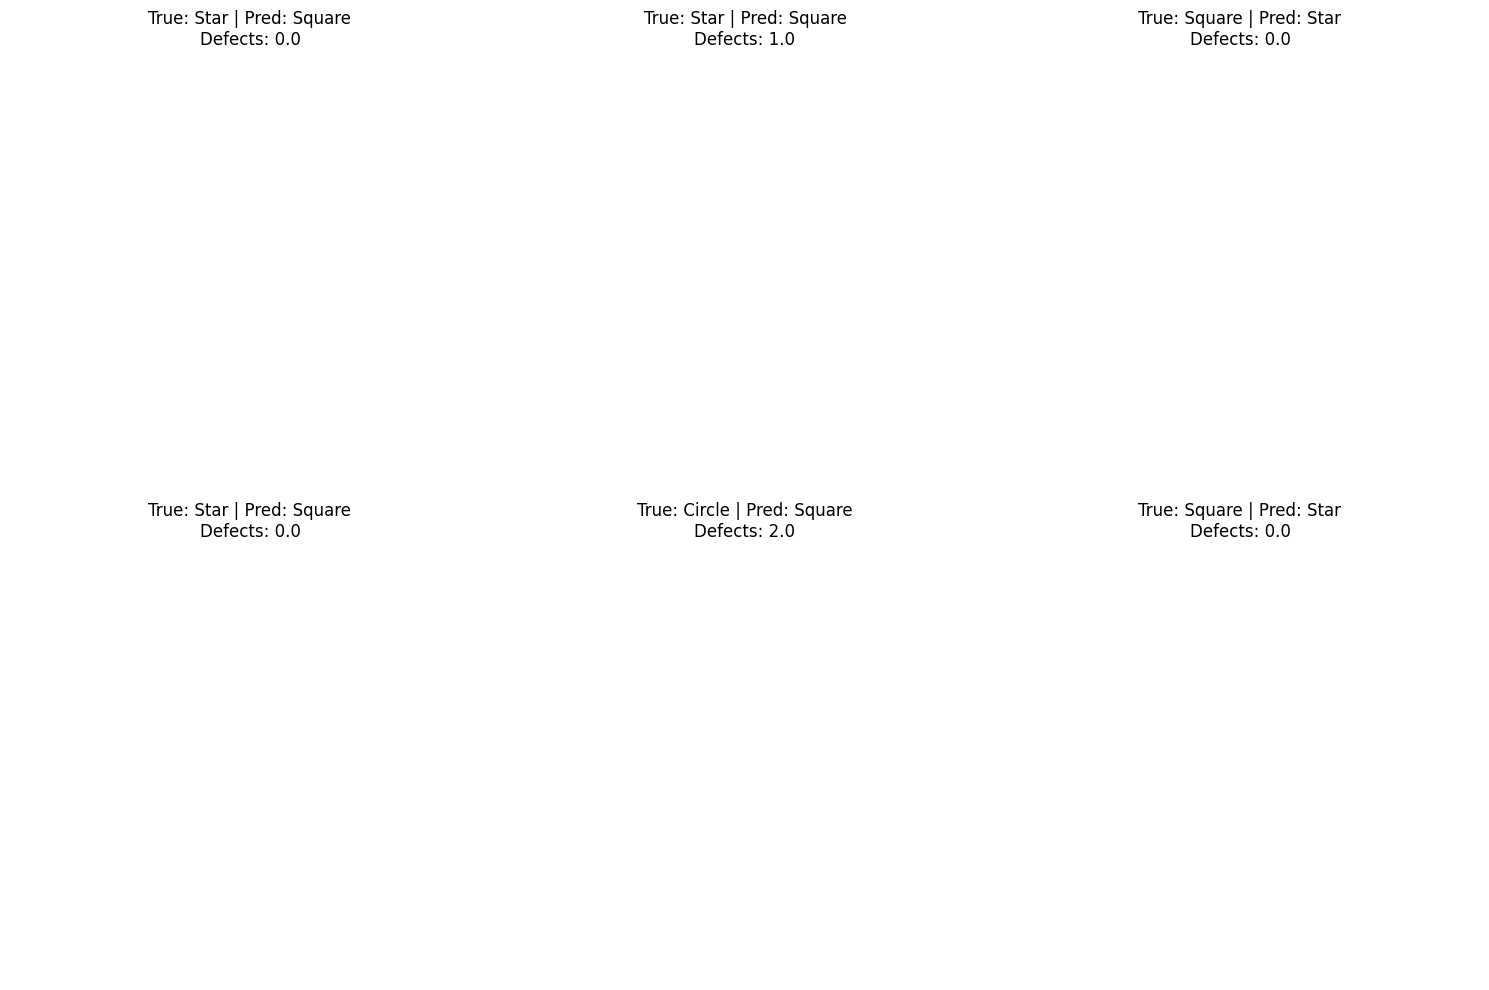

In [32]:
import matplotlib.pyplot as plt

# Identify the indices where the prediction was wrong
errors = np.where(y_test != y_pred)[0]

print(f"Displaying a sample of the {len(errors)} misclassifications...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ax_idx in enumerate(errors[:6]): # Show first 6 errors
    # Re-extract the original row data to find the matching image
    # Note: If you shuffled before splitting, you'll need the original filename.
    # This snippet assumes you track filenames alongside your X array.
    
    true_label = y_test[ax_idx]
    pred_label = y_pred[ax_idx]
    features = X_test_reduced[ax_idx]
    
    axes[i].set_title(f"True: {true_label} | Pred: {pred_label}\nDefects: {features[5]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### See output

## Save the model for `main_vision.py`

In [33]:
joblib.dump(xgb_model, "shape_classifier.pkl")
print("Saved shape_classifier.pkl")

Saved shape_classifier.pkl


## Train w RF


In [ ]:
##clf = RandomForestClassifier(
  ##  n_estimators=200,
   ## class_weight="balanced",
    ##random_state=42
##)
##clf.fit(X_train, y_train)

##y_pred = clf.predict(X_test)
##print(classification_report(y_test, y_pred))
